<a href="https://colab.research.google.com/github/himabindusgs-svg/LinearRegression/blob/main/Smart_E_Commerce_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:

   Purchase_Amount  Website_Visits  Actual_Label
0              500               2             0
1              700               3             0
2             1000               4             0
3             3000              10             1
4             4000              12             1
5             5000              15             1
6             9000              25             2
7            10000              28             2
8            12000              30             2
   Purchase_Amount  Website_Visits  Actual_Label
0              500               2             0
1              700               3             0
2             1000               4             0
3             3000              10             1
4             4000              12             1
5             5000              15             1
6             9000              25             2
7            10000              28             2
8            12000              30             2

Predicted

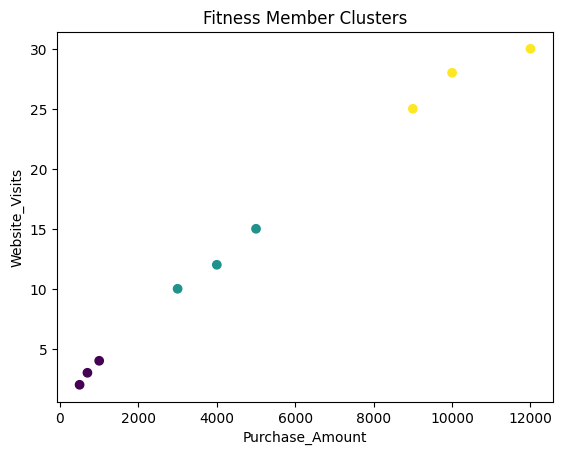

In [6]:
# Hands-On Activity — K-Means Clustering + Metrics (Different Scenario)
# PROJECT TITLE
# Smart E-Commerce Customer Segmentation
# SCENARIO
# An e-commerce company wants AI to analyze customer shopping behavior and automatically group customers into:
# Low Value Customers
# Medium Value Customers
# High Value Customers
# based on:
# Monthly Purchase Amount
# Website Visit Count
# The company also wants to compare AI-generated groups with known labels and understand:
# ✅ Accuracy
# ✅ Precision
# ✅ Recall
# This helps connect:
# K-Means Clustering
# Evaluation Metrics
# Real-world AI workflows

# Purchase_Amount,Website_Visits,Actual_Label
# 500,2,0
# 700,3,0
# 1000,4,0
# 3000,10,1
# 4000,12,1
# 5000,15,1
# 9000,25,2
# 10000,28,2
# 12000,30,2
# Actual_LabelﾠMeaning
# 0ﾠLow Value Customer
# 1ﾠMedium Value Customer
# 2ﾠHigh Value Customer



# ============================================
# FITNESS MEMBER SEGMENTATION PROJECT
# K-Means + Metrics
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)


# ============================================
# Create Dataset
# ============================================

# STEP 2 — Upload CSV file

uploaded = files.upload()


# STEP 3 — Load dataset

df = pd.read_csv("ActualPurchase.csv")


# STEP 4 — Display dataset

print("Dataset:\n")
print(df)


print(df)


# ============================================
# Select Input Features
# ============================================

X = df[['Purchase_Amount','Website_Visits']]


# ============================================
# Train K-Means
# ============================================

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)


# ============================================
# Predict Clusters
# ============================================

predicted = model.labels_
df['Predicted'] = predicted


print("\nPredicted Clusters\n")

print(predicted)


# ============================================
# IMPORTANT:
# K-Means labels are random
# ============================================

print("\nCluster Centers\n")

print(model.cluster_centers_)


# Actual learned clusters:

# Cluster 2 → Low
# Cluster 0 → Medium
# Cluster 1 → High


cluster_mapping = {

2:0,
0:1,
1:2

}


df['Mapped_Predicted'] = (
    df['Predicted']
    .map(cluster_mapping)
)
# Human-friendly labels

activity_map = {

0:'Low Activity',
1:'Medium Activity',
2:'High Activity'

}


df['Activity_Level']=(
    df['Mapped_Predicted']
    .map(activity_map)
)


print("\nUpdated Dataset\n")

print(df)


# ============================================
# Evaluation
# ============================================

accuracy = accuracy_score(

    df['Actual_Label'],

    df['Mapped_Predicted']

)


precision = precision_score(

    df['Actual_Label'],

    df['Mapped_Predicted'],

    average='macro'
    )


recall = recall_score(

    df['Actual_Label'],

    df['Mapped_Predicted'],

    average='macro'

)


print("\nAccuracy:",accuracy)

print("Precision:",precision)

print("Recall:",recall)


# ============================================
# Visualization
# ============================================

plt.scatter(

    df['Purchase_Amount'],

    df['Website_Visits'],

    c=df['Mapped_Predicted']

)

plt.xlabel("Purchase_Amount")

plt.ylabel("Website_Visits")

plt.title(
    "Fitness Member Clusters"
    )

plt.show()